In [67]:
import os
import numpy as np
import sys
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [68]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(os.path.dirname(script_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot


In [69]:
# load old sheets

root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
latent_array = joblib.load(os.path.join(root_dir, 'latent_array_plus6_ctrl_y.pkl'))
label_folder = '/mnt/d/lding/FA/analysis_results/labelling'
patch_label_df = pd.read_csv(os.path.join(root_dir, 'patch_label_df_lat9umap2.csv'))
lat8_margaret_label_121922 = pd.read_csv(os.path.join(root_dir, 'lat8_margaret_label_121922.csv'))
pi_Y_fa_1000_df = pd.read_csv(os.path.join(label_folder, 'Margaret_Ycomp_V2_project-20-at-2026-02-09-21-40-9d1e4d7c.csv'))
pi_C_200_df = pd.read_csv(os.path.join(label_folder, 'Margaret_Control_V2_project-19-at-2026-02-09-21-46-5552392a.csv'))

In [70]:
def ctrl_Y_ID_adding(label_df):
    label_df["group"] = (
    label_df["czi_filename"]
    .str.lower()
    .str.extract(r"(control|ycomp)", expand=False)
    )
  
    label_df["group_ID"] = label_df["group"].map(
    {"control": 0, "ycomp": 1}
    )


    label_df["unique_ID"]  = label_df["group"] +'-'+label_df["crop_img_filename"] 

    return label_df
        

In [71]:
pi_Y_fa_1000_df = ctrl_Y_ID_adding(pi_Y_fa_1000_df)
pi_C_200_df = ctrl_Y_ID_adding(pi_C_200_df)

In [72]:


random_set_2_batches = (
    pd.concat([lat8_margaret_label_121922, pi_C_200_df], ignore_index=True)
      .drop_duplicates(subset="unique_ID", keep="last")  # df2 is last -> wins
      .reset_index(drop=True)
)

In [73]:
batch1_random = random_set_2_batches.copy()

import pandas as pd

# 0) Make sure IDs match type
batch1_random = batch1_random.copy()
pi_Y_fa_1000_df = pi_Y_fa_1000_df.copy()

batch1_random["unique_ID"] = batch1_random["unique_ID"].astype(str)
pi_Y_fa_1000_df["unique_ID"] = pi_Y_fa_1000_df["unique_ID"].astype(str)

# 1) Find duplicate IDs (intersection)
dup_ids = batch1_random["unique_ID"].isin(pi_Y_fa_1000_df["unique_ID"])
dup_id_values = batch1_random.loc[dup_ids, "unique_ID"].unique()

print("Duplicates found:", len(dup_id_values))

# 2) Update batch1_random rows with labels from PI df (PI wins)
#    Pick which columns to overwrite: all shared columns except unique_ID
overwrite_cols = list((set(batch1_random.columns) & set(pi_Y_fa_1000_df.columns)) - {"unique_ID"})

# Index both by unique_ID for fast aligned update
b1_idx = batch1_random.set_index("unique_ID")
pi_idx = pi_Y_fa_1000_df.set_index("unique_ID")

# Only update overlapping IDs + overlapping columns
b1_idx.loc[dup_id_values, overwrite_cols] = pi_idx.loc[dup_id_values, overwrite_cols]

batch1_random_updated = b1_idx.reset_index()

# 3) Remove those samples from PI df
pi_Y_fa_1000_df_remaining = pi_Y_fa_1000_df[~pi_Y_fa_1000_df["unique_ID"].isin(dup_id_values)].copy()

print("PI df remaining rows:", len(pi_Y_fa_1000_df_remaining))
print("Batch1 rows updated:", len(dup_id_values))


Duplicates found: 4
PI df remaining rows: 755
Batch1 rows updated: 4


In [74]:
# CODEX CHANGED: define latent_cols and extract unique_ID + latents from patch_label_df
# Keep latent dimensions from patch_label_df for downstream training merge
latent_cols = [f"lat_d{i}" for i in range(8)]
patch_latent_cols = ["unique_ID", *latent_cols]

missing_latent_cols = [c for c in patch_latent_cols if c not in patch_label_df.columns]
if missing_latent_cols:
    raise KeyError(f"Missing expected columns in patch_label_df: {missing_latent_cols}")

patch_label_df_lat = (
    patch_label_df[patch_latent_cols]
    .copy()
    .drop_duplicates(subset="unique_ID", keep="last")
)

patch_label_df_lat.head()


,unique_ID,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7
0,control-f0000x0080y0816ps32.tif,4.793272,20.604002,5.372108,-7.815341,1.760113,32.959721,-21.882824,2.258103
1,control-f0000x0112y0784ps32.tif,0.826394,-3.398712,-2.768886,5.473682,-1.714877,1.444764,-5.044192,-2.793007
2,control-f0000x0144y0784ps32.tif,10.628540,3.866692,-0.625196,2.456605,0.941578,6.303121,-6.728461,-7.896038
3,control-f0000x0176y0784ps32.tif,13.097126,9.377098,7.463983,-0.638954,3.322603,22.364613,-18.249426,0.339599
4,control-f0000x0240y0752ps32.tif,15.051421,4.962876,1.968619,4.266151,3.475077,12.175271,-11.814137,-9.985755


In [75]:
# CODEX CHANGED: enrich pi_Y_fa_1000_df_remaining with lat_d0-lat_d7 via merge
# Consolidate updated labels (PI updates + remaining PI rows)
b1 = batch1_random_updated.copy()
pi = pi_Y_fa_1000_df_remaining.copy()

# Ensure pi_Y_fa_1000_df_remaining itself carries latent dimensions
pi["unique_ID"] = pi["unique_ID"].astype(str)
patch_label_df_lat["unique_ID"] = patch_label_df_lat["unique_ID"].astype(str)

pi = pi.merge(patch_label_df_lat, on="unique_ID", how="left", validate="m:1")
pi_Y_fa_1000_df_remaining = pi

missing_pi_lat = pi_Y_fa_1000_df_remaining[latent_cols].isna().all(axis=1).sum()
print("PI remaining rows missing all latent dims:", int(missing_pi_lat))

b1["sample_weight"] = 1.0
pi_Y_fa_1000_df_remaining["sample_weight"] = 1

labels_updated = (
    pd.concat([b1, pi_Y_fa_1000_df_remaining], ignore_index=True)
    .drop_duplicates(subset="unique_ID", keep="last")
)

labels_updated.shape


PI remaining rows missing all latent dims: 0


(1340, 52)

In [76]:
# CODEX CHANGED: final merge keeps latent base and attaches labels
# Merge labels onto patch-level latent features
# left merge keeps patch rows/latents; labels populate where available
df = patch_label_df_lat.merge(labels_updated, on="unique_ID", how="left")

print("Rows with labels:", df["classification"].notna().sum())
print("Rows without labels:", df["classification"].isna().sum())
print("Latent columns present:", [c for c in latent_cols if c in df.columns])


Rows with labels: 1340
Rows without labels: 22316
Latent columns present: []


In [77]:
# CODEX CHANGED: keep labeled/non-Uncertain rows only
# Keep trainable labeled rows only
df_clean = df[df["classification"].notna() & (df["classification"] != "Uncertain")].copy()
df_clean.shape


(1310, 60)

In [78]:
lat_cols = [f'lat_d{i}' for i in range(8)]

for col in lat_cols:
    df_clean[col] = df_clean[f'{col}_x'].combine_first(df_clean[f'{col}_y'])

# Drop the original _x and _y columns
df_clean = df_clean.drop(columns=[f'{col}_x' for col in lat_cols] + 
                                  [f'{col}_y' for col in lat_cols])

In [79]:
df_clean.to_csv(os.path.join(root_dir, 'label_20260223_combined_lat8_equalweight.csv'))

In [10]:
check_duplicate = pd.merge(lat8_margaret_label_121922,pi_C_200_df,on='unique_ID',how='outer')


In [23]:
df_a = lat8_margaret_label_121922
df_b = pi_Y_fa_1000_df

In [24]:
import pandas as pd

# 1) Keep rows from df_a that are also in df_b (duplicates across sets)
dup_a = df_a[df_a["unique_ID"].isin(df_b["unique_ID"])].copy()

# 2) Keep rows from df_b that are also in df_a
dup_b = df_b[df_b["unique_ID"].isin(df_a["unique_ID"])].copy()

In [25]:
dups = df_a.merge(
    df_b,
    on="unique_ID",
    how="inner",
    suffixes=("_a", "_b")
)

In [26]:
dups[['Position_a','Position_b','classification_a','classification_b']]

,Position_a,Position_b,classification_a,classification_b
0,Cell Periphery/other,Cell Periphery/other,No adhesion,No adhesion
1,Cell Protruding Edge,Cell Protruding Edge,focal complex,Nascent Adhesion
2,Cell Periphery/other,Cell Periphery/other,focal complex,focal adhesion
3,Cell Protruding Edge,Cell Protruding Edge,Nascent Adhesion,Nascent Adhesion


In [28]:
patch_label_df_trainval_MSE = pd.read_csv(os.path.join(root_dir,"patch_label_df_trainval_MSE_lesscol.csv"))

In [29]:
patch_label_df_trainval_MSE.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0',
       'ctrl_y_str', 'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'vinculin_intensity', 'pax_intensity',
       'actin_intensity', 'dist_cell_edge', 'front_flag', 'lat_d0', 'lat_d1',
       'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'group',
       'unique_ID', 'FA_class_based_pred', 'position_based_pred',
       'jointlabel_based_pred', 'train_val_flag', 'group_ID', 'y_corner4',
       'x_corner4', 'x_corner2', 'rand_angle', 'y_corner3', 'rand_ty',
       'x_corner1', 'x_corner3', 'movie_partitioned_data_dir', 'y_corner2',
       'filenameID', 'plot_filename', 'x_c', 'movie_plot_dir', 'image_folder',
       'rand_tx', 'filename', 'y_c', 'y_corner1', 'AE_MSE'],
      dtype='object')

In [36]:
classification_label_order = [
    "Nascent Adhesion",
    "focal complex",
    "focal adhesion",
    "fibrillar adhesion",
    "No adhesion",
    "Uncertain",
]

position_label_order = [
    "Cell Protruding Edge",
    "Cell Periphery/other",
    "Lamella",
    "Cell Body",
    "No Category/uncertain",
]

fa_id_to_label = {
     i :label
    for i, label in enumerate(classification_label_order)
}
position_id_to_label = {
    i: label
    for i, label in enumerate(position_label_order)
}

fa_label_to_id = {
    label: i
    for i, label in enumerate(classification_label_order)
}

position_label_to_id = {
    label: i
    for i, label in enumerate(position_label_order)
}

In [80]:
df.shape

(1340, 52)

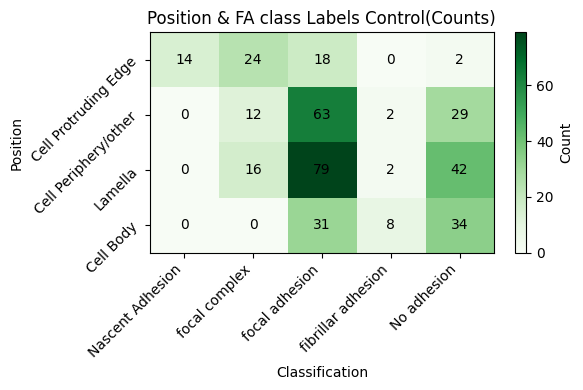

In [90]:
mask = df["group_ID"] ==0


df["classification_id"] = df['classification'].map(fa_label_to_id)
df["Position_id"] = df['Position'].map(position_label_to_id)
y_position_all_pred = df['Position_id']
y_FA_class_all_pred = df['classification_id']

ct_pred = pd.crosstab(
    y_position_all_pred[mask], y_FA_class_all_pred[mask])

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct_pred.values[0:4, 0:5], cmap="Greens", aspect="auto")


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Position & FA class Labels Control(Counts)")

# annotate cells
for i in range(ct_pred.shape[0]-1):
    for j in range(ct_pred.shape[1]-1):
        ax.text(j, i, ct_pred.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

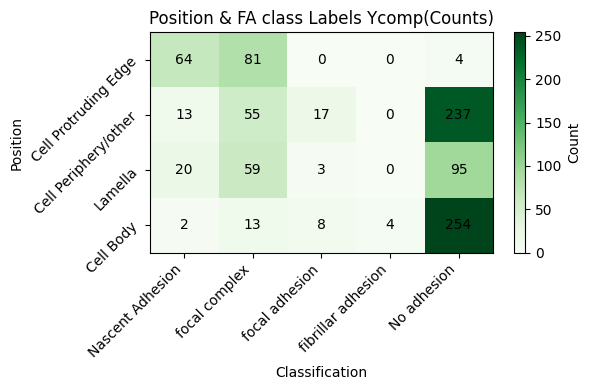

In [91]:
mask = df["group_ID"] ==1


df["classification_id"] = df['classification'].map(fa_label_to_id)
df["Position_id"] = df['Position'].map(position_label_to_id)
y_position_all_pred = df['Position_id']
y_FA_class_all_pred = df['classification_id']

ct_pred = pd.crosstab(
    y_position_all_pred[mask], y_FA_class_all_pred[mask])

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct_pred.values[0:4, 0:5], cmap="Greens", aspect="auto")


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Position & FA class Labels Ycomp(Counts)")

# annotate cells
for i in range(ct_pred.shape[0]-1):
    for j in range(ct_pred.shape[1]-1):
        ax.text(j, i, ct_pred.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

In [ ]:
############# Liya to do
# load the two new csv
# combine with old 
# save
# plot out 2D counts

# then in classification notebooks, prepare v2, where labels are V2